In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2


In [ ]:
# Step 2: Load Dataset
df = pd.read_csv("customer_behavior.csv")

# Step 3: Inspect Dataset
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget variable distribution:\n", df['HighValueCustomer'].value_counts())



Dataset shape: (70000, 41)

Data types:
 CustomerID                  int64
Sector                     object
Region                     object
Age                       float64
Income                    float64
SatisfactionScore           int64
PreviousComplaints          int64
ChurnRisk                  object
NumTransactions             int64
HasMembership               int64
MembershipDuration          int64
AvgTransactionValue       float64
WebVisits                   int64
SupportTickets              int64
ReturnedItems               int64
ReferralSource             object
FeedbackScore             float64
AccountAgeMonths            int64
LatePayments                int64
MobileAppUsage              int64
Gender                     object
EducationLevel             object
MaritalStatus              object
OwnsCar                     int64
OwnsHouse                   int64
Children                    int64
ProductViews                int64
CouponsUsed                 int64
LoggedI

In [ ]:
# Step 4: Handle Missing Values
# Fill numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)
# Fill categorical with mode
df.fillna(df.mode().iloc[0], inplace=True)


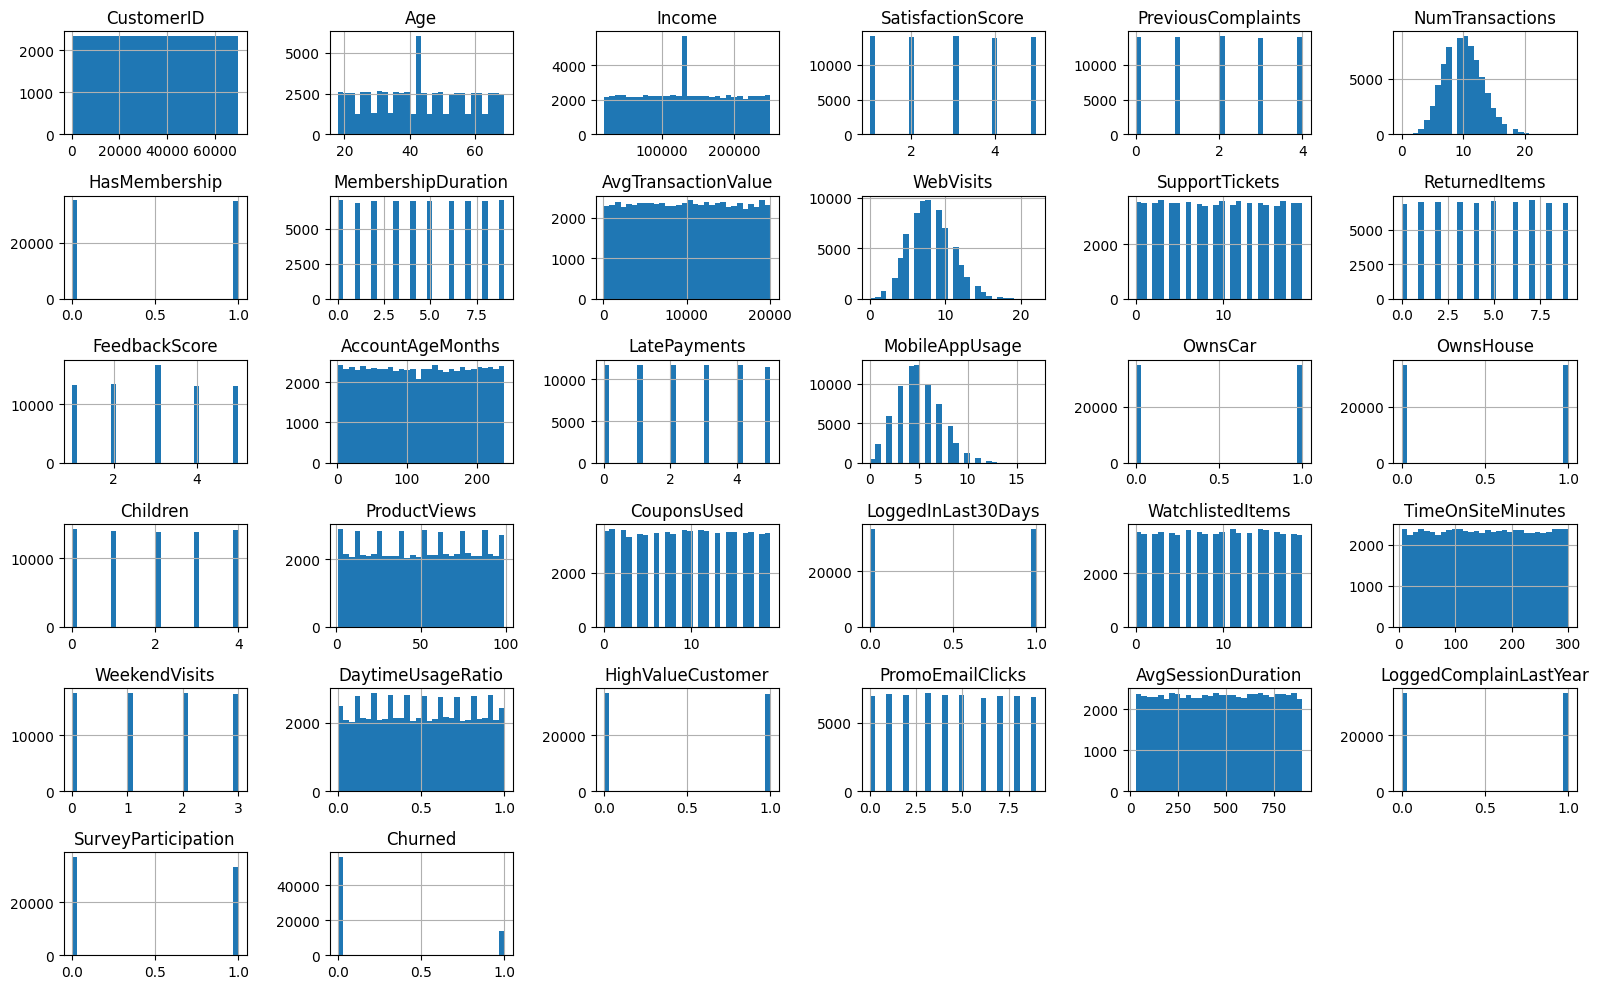

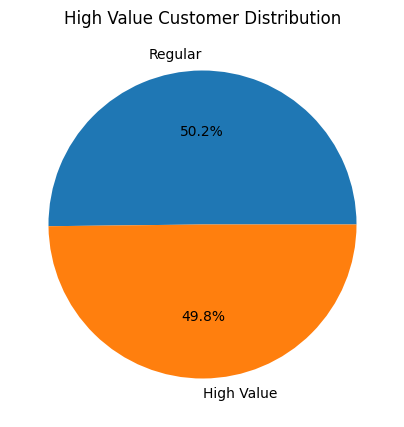

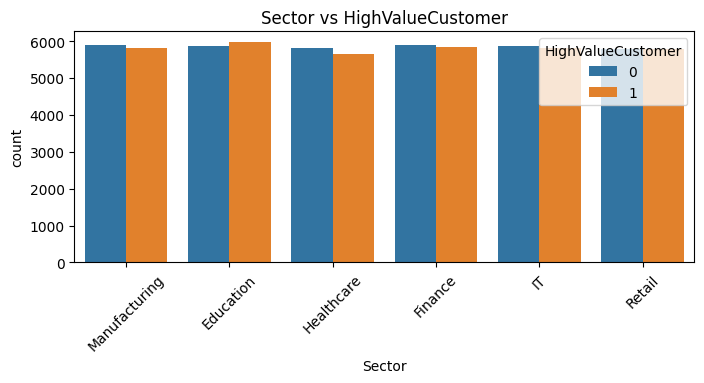

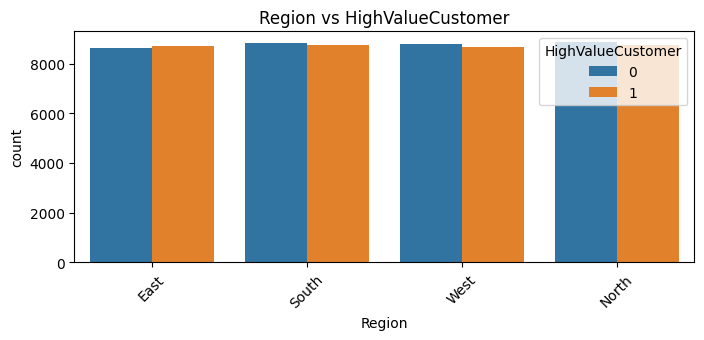

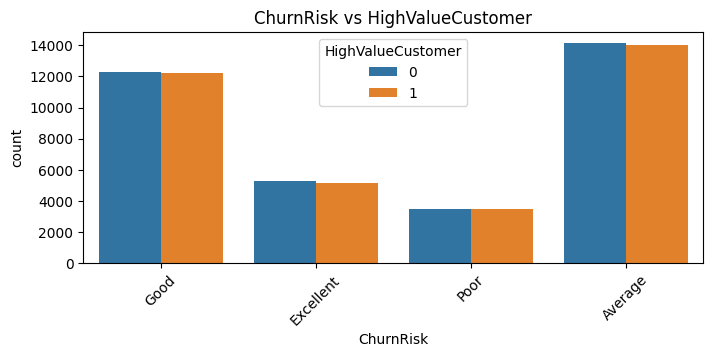

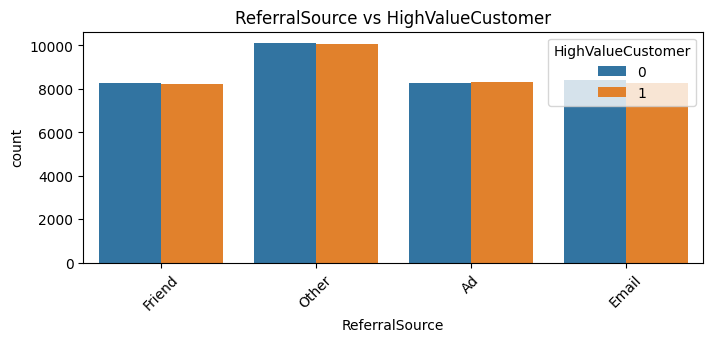

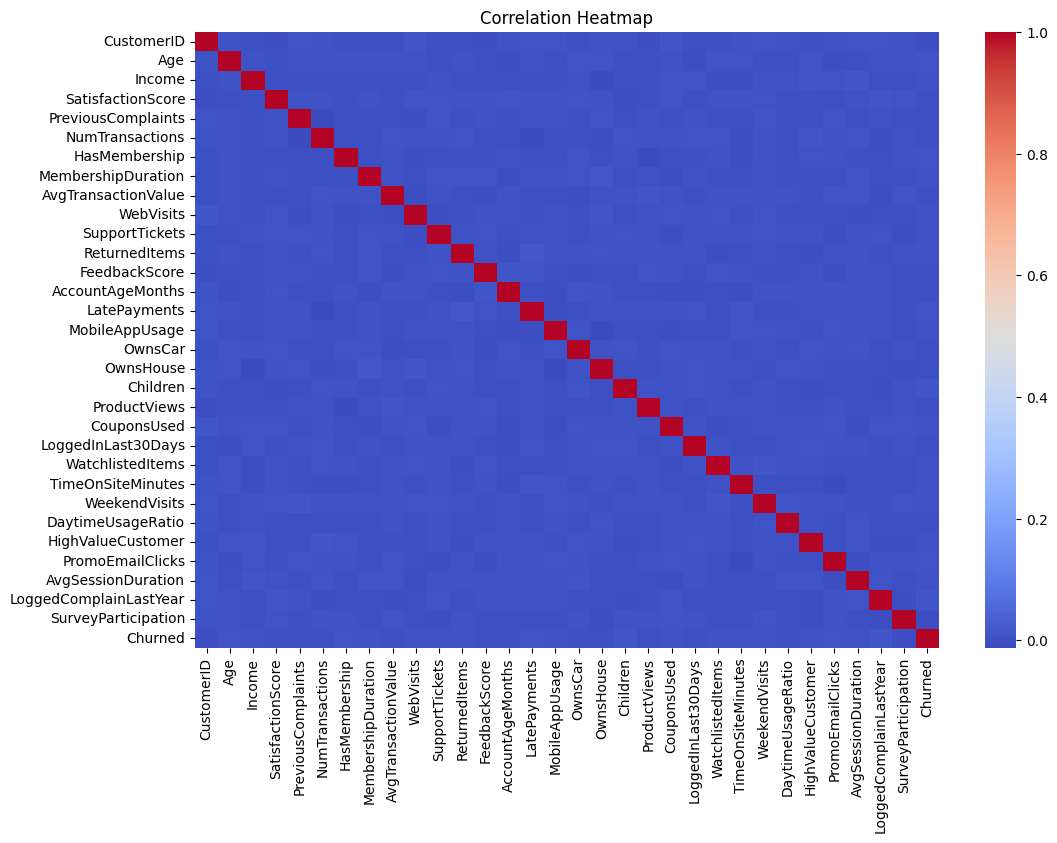

In [ ]:
# Step 5: Visualizations
# Histogram of numerical columns
df.select_dtypes(include=np.number).hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()

# Pie chart for target variable
plt.figure(figsize=(5, 5))
df['HighValueCustomer'].value_counts().plot.pie(autopct='%1.1f%%', labels=["Regular", "High Value"])
plt.title("High Value Customer Distribution")
plt.ylabel("")
plt.show()

# Bar plot for a few categorical columns
cat_cols = df.select_dtypes(include='object').columns[:4]
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(data=df, x=col, hue='HighValueCustomer')
    plt.title(f"{col} vs HighValueCustomer")
    plt.xticks(rotation=45)
    plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()



In [ ]:
# Step 6: Encode Categorical Columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 7: Feature Scaling
scaler = StandardScaler()
X = df_encoded.drop("HighValueCustomer", axis=1)
y = df_encoded["HighValueCustomer"]

X_scaled = scaler.fit_transform(X)


In [ ]:

# Step 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Define the model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5016 - loss: 0.8050 - val_accuracy: 0.4972 - val_loss: 0.7315
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5085 - loss: 0.7215 - val_accuracy: 0.4947 - val_loss: 0.7026
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5048 - loss: 0.6995 - val_accuracy: 0.5016 - val_loss: 0.6943
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4961 - loss: 0.6938 - val_accuracy: 0.5016 - val_loss: 0.6932
Epoch 5/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4939 - loss: 0.6932 - val_accuracy: 0.5016 - val_loss: 0.6931
Epoch 6/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.4984 - val_loss: 0.6932
Epoch 7/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4935 - loss: 0.6932 - val_accuracy: 0.5016 - val_loss: 0.6932
Epoch 8/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accurac

In [ ]:

# Step 11: Evaluate the Model
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy Score: 0.5017857142857143
Confusion Matrix:
 [[7025    0]
 [6975    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67      7025
           1       0.00      0.00      0.00      6975

    accuracy                           0.50     14000
   macro avg       0.25      0.50      0.33     14000
weighted avg       0.25      0.50      0.34     14000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


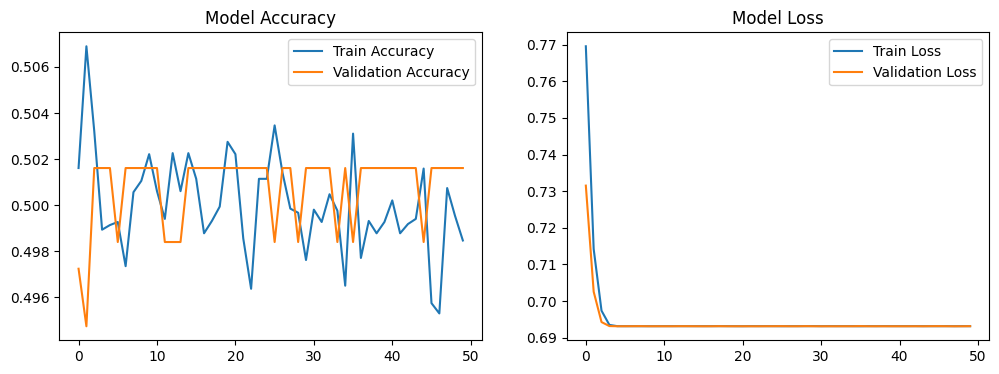

In [ ]:

# Step 12: Plot Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()